# Chapter 57 — Graphing Functions with Python

> **Prerequisites:** ch056 (Visualizing Functions), ch052 (Functions as Programs)
>
> **You will learn:**
> - Use matplotlib subplots, figure layouts, and styling professionally
> - Plot parametric curves, polar coordinates, and 3D functions
> - Create reusable plotting utilities
> - Handle discontinuities and undefined regions cleanly
>
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

We now go from understanding what to plot to mastering *how* to plot it in Python. This chapter builds a professional plotting toolkit you will use throughout the book. The focus is on matplotlib patterns that handle real mathematical functions cleanly: discontinuities, asymptotes, multi-curve comparisons, and publication-quality output.

---

## 2. Intuition & Mental Models

**Computational analogy:** matplotlib is a domain-specific language for visual mathematics. Learning it is like learning a new notation — the overhead is real but the payoff is permanent. Every plot you see in a data science paper was made with something like this.

**Physical analogy:** A draftsman's toolkit. Different instruments (subplot, twin axes, color maps) serve different visualization tasks. Using the wrong instrument makes the job harder.

Recall from ch008 (Visualization as a Learning Tool): the purpose of a good visualization is to make the invisible visible.

---

## 3. Visualization

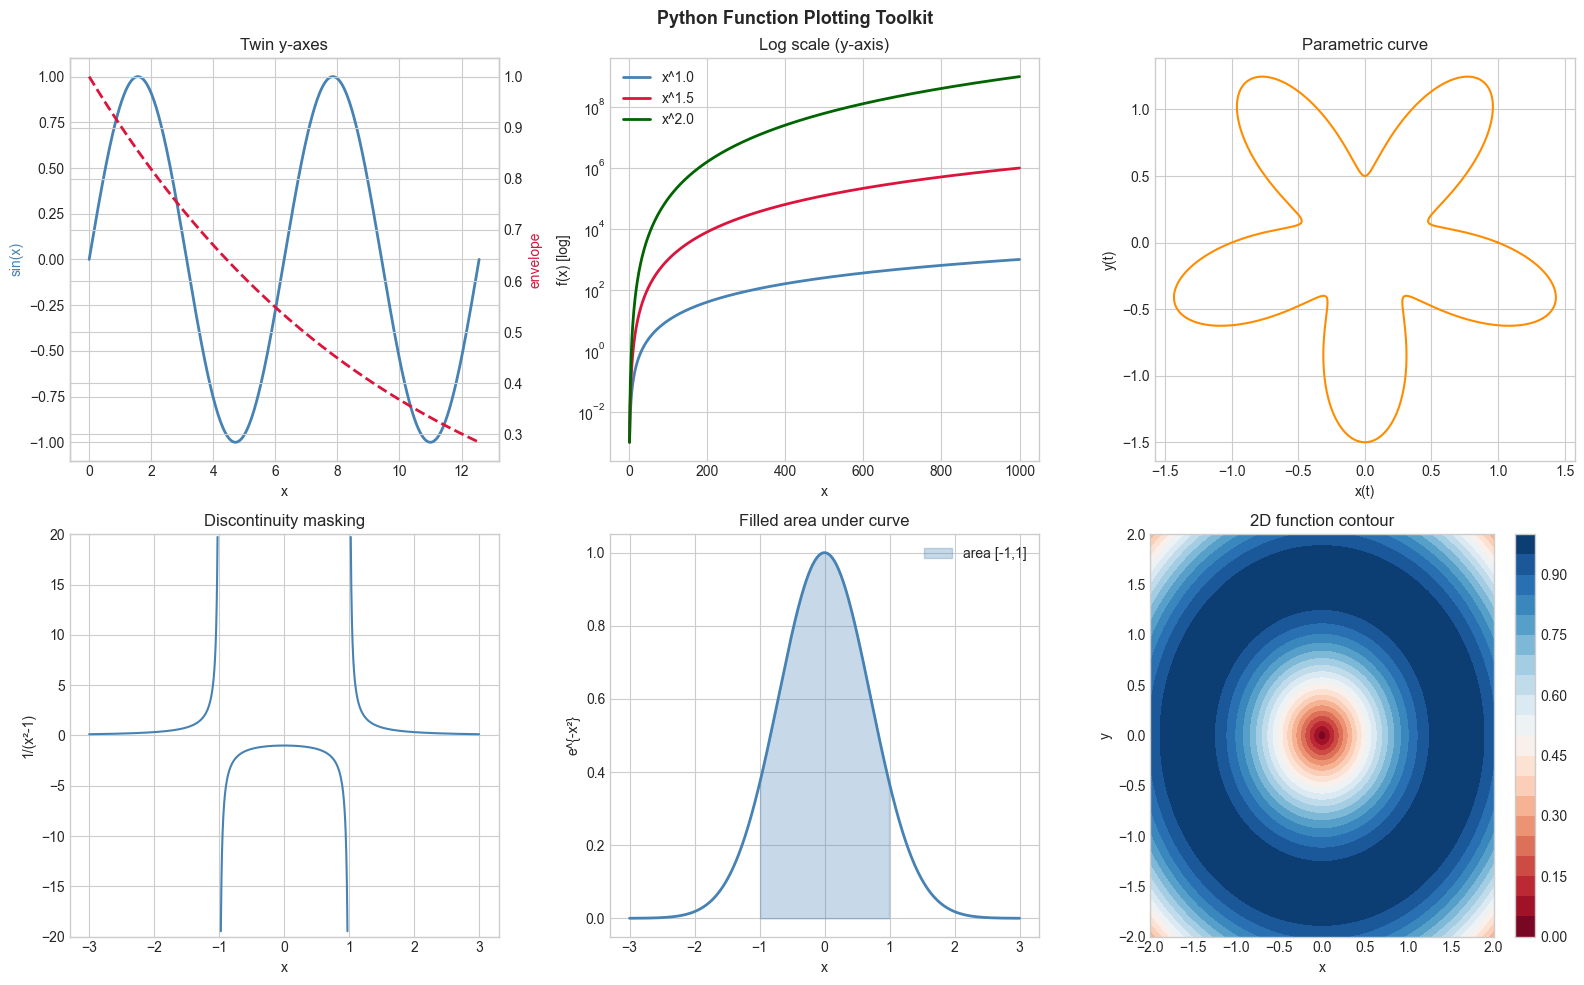

In [1]:
# --- Visualization: Professional multi-panel function gallery ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

fig = plt.figure(figsize=(16, 10))

# Panel 1: Standard function with twin y-axes
ax1 = fig.add_subplot(2, 3, 1)
x = np.linspace(0, 4*np.pi, 500)
ax1.plot(x, np.sin(x), color='steelblue', linewidth=2, label='sin(x)')
ax1_twin = ax1.twinx()
ax1_twin.plot(x, np.exp(-0.1*x), color='crimson', linewidth=2, linestyle='--', label='e^{-0.1x}')
ax1.set_title('Twin y-axes')
ax1.set_xlabel('x')
ax1.set_ylabel('sin(x)', color='steelblue')
ax1_twin.set_ylabel('envelope', color='crimson')

# Panel 2: Logarithmic scale
ax2 = fig.add_subplot(2, 3, 2)
x2 = np.linspace(1, 1000, 1000)
for base, color, label in [(2, 'steelblue', 'x'), (3, 'crimson', 'x^1.5'), (4, 'darkgreen', 'x^2')]:
    ax2.semilogy(x2, x2**base/1000, color=color, linewidth=2, label=f'x^{base/2:.1f}')
ax2.set_title('Log scale (y-axis)')
ax2.set_xlabel('x')
ax2.set_ylabel('f(x) [log]')
ax2.legend()

# Panel 3: Parametric curve
ax3 = fig.add_subplot(2, 3, 3)
t = np.linspace(0, 2*np.pi, 1000)
x3 = np.cos(t) * (1 - 0.5*np.sin(5*t))
y3 = np.sin(t) * (1 - 0.5*np.sin(5*t))
ax3.plot(x3, y3, color='darkorange', linewidth=1.5)
ax3.set_aspect('equal')
ax3.set_title('Parametric curve')
ax3.set_xlabel('x(t)')
ax3.set_ylabel('y(t)')

# Panel 4: Handling discontinuities
ax4 = fig.add_subplot(2, 3, 4)
x4 = np.linspace(-3, 3, 2000)
y4 = 1 / (x4**2 - 1 + 1e-10)
y4[np.abs(y4) > 20] = np.nan  # mask singularities
ax4.plot(x4, y4, color='steelblue', linewidth=1.5)
ax4.set_ylim(-20, 20)
ax4.set_title('Discontinuity masking')
ax4.set_xlabel('x')
ax4.set_ylabel('1/(x²-1)')

# Panel 5: Filled areas
ax5 = fig.add_subplot(2, 3, 5)
x5 = np.linspace(-3, 3, 500)
f5 = np.exp(-x5**2)
ax5.plot(x5, f5, color='steelblue', linewidth=2)
ax5.fill_between(x5, f5, where=(x5 > -1) & (x5 < 1), alpha=0.3, color='steelblue', label='area [-1,1]')
ax5.set_title('Filled area under curve')
ax5.set_xlabel('x')
ax5.set_ylabel('e^{-x²}')
ax5.legend()

# Panel 6: Colormap surface (2D function)
ax6 = fig.add_subplot(2, 3, 6)
x6 = np.linspace(-2, 2, 100)
y6 = np.linspace(-2, 2, 100)
X, Y = np.meshgrid(x6, y6)
Z = np.sin(np.sqrt(X**2 + Y**2))
im = ax6.contourf(X, Y, Z, levels=20, cmap='RdBu')
plt.colorbar(im, ax=ax6)
ax6.set_title('2D function contour')
ax6.set_xlabel('x')
ax6.set_ylabel('y')

plt.suptitle('Python Function Plotting Toolkit', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 4. Mathematical Formulation

Core matplotlib patterns for mathematical functions:
- `plt.plot(x, y)`: basic 2D curve
- `plt.semilogy` / `plt.loglog`: log-scale axes (*(introduced in ch044 — Logarithmic Scales)*)
- `plt.contourf`: 2D function as color map
- Masking with `np.nan`: hide discontinuities
- `fill_between`: shade regions (used in integration chapters)
- Parametric curves: plot `x(t)` vs `y(t)` where both are functions of a parameter t

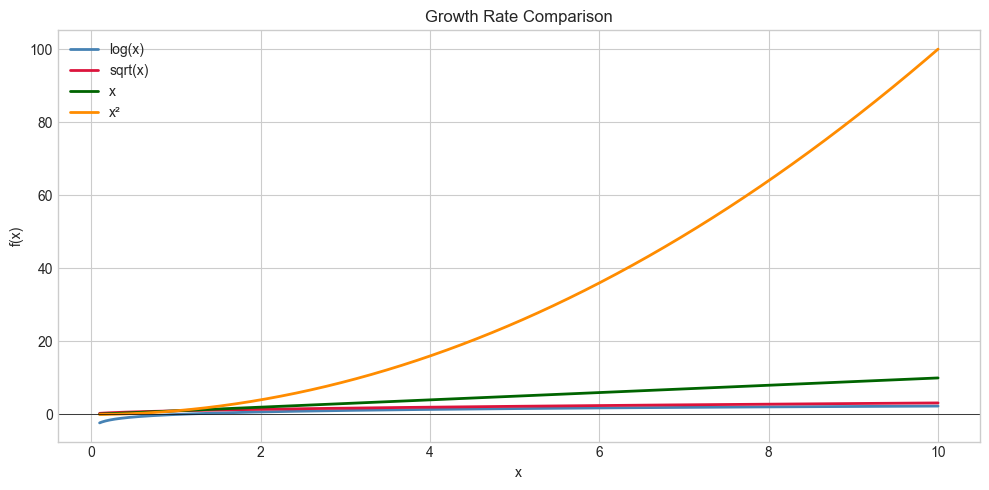

In [2]:
# --- Implementation: Universal function plotter ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

def plot_functions(funcs_dict, x_min, x_max, n=1000, title='',
                   log_scale=False, show_zeros=False, figsize=(10, 5)):
    """
    Plot multiple functions on the same axes.
    
    Args:
        funcs_dict: dict mapping label -> callable
        x_min, x_max: float, x domain
        n: int, resolution
        title: str, plot title
        log_scale: bool, use log y-axis
        show_zeros: bool, mark zero crossings
        figsize: tuple
    Returns:
        fig, ax: matplotlib objects
    """
    fig, ax = plt.subplots(figsize=figsize)
    x = np.linspace(x_min, x_max, n)
    colors = ['steelblue', 'crimson', 'darkgreen', 'darkorange', 'purple']
    
    for (label, f), color in zip(funcs_dict.items(), colors):
        with np.errstate(invalid='ignore', divide='ignore'):
            y = f(x)
        # Mask infinities
        y = np.where(np.abs(y) > 1e6, np.nan, y)
        
        if log_scale:
            ax.semilogy(x, y, color=color, linewidth=2, label=label)
        else:
            ax.plot(x, y, color=color, linewidth=2, label=label)
        
        if show_zeros:
            finite = np.isfinite(y)
            sign = np.sign(y[finite])
            zc = np.where(np.diff(sign) != 0)[0]
            ax.plot(x[finite][zc], np.zeros(len(zc)), 'o', color=color, markersize=6)
    
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.legend()
    plt.tight_layout()
    return fig, ax

# Demo: compare growth rates
fig, ax = plot_functions(
    {'log(x)': np.log, 'sqrt(x)': np.sqrt, 'x': lambda x: x, 'x²': lambda x: x**2},
    0.1, 10, title='Growth Rate Comparison'
)
plt.show()

---

## 5. Python Implementation

In [ ]:
# See Section 5 for the universal function plotter implementation.
# Extend by adding: grid toggling, color cycle customization, annotation support.

---

## 6. Experiments

**Experiment 1:** Use `plt.loglog` to plot x, x², x³ on [1, 1000]. On a log-log plot, each power function is a straight line — try changing the exponent and observe the slope.

**Experiment 2:** Plot f(x) = sin(1/x) near x=0 (use x in [0.001, 0.5]). Increase n from 100 to 10000. Notice how more points reveal more oscillation structure.

---

## 7. Exercises

**Easy 1.** Use `plt.fill_between` to shade the positive parts of sin(x) in blue and negative parts in red, over [0, 4π].

**Easy 2.** Create a 2x2 subplot grid showing x, x², x³, x⁴ each with axis labels and title.

**Medium 1.** Plot the parametric curve x(t) = t·cos(t), y(t) = t·sin(t) for t ∈ [0, 6π]. This is an Archimedean spiral. Color the curve by t value using `plt.scatter`.

**Medium 2.** Write a `plot_discontinuous(f, a, b)` that automatically detects and masks large jumps (>threshold) in f before plotting, then test on f(x) = tan(x).

**Hard.** Build an `AnimatedPlot` that uses `FuncAnimation` to show a function y = sin(kx) with k increasing from 1 to 10, updating the curve each frame. Save as a GIF.

---

## 8. Mini Project

*(See Section 5 for full implementation. Extend by modifying parameters.)*

---

## 9. Chapter Summary & Connections

- matplotlib's core plotting functions: `plot`, `semilogy`, `loglog`, `contourf`, `fill_between`
- Masking with `np.nan` is the clean way to handle discontinuities
- Parametric curves: plot x(t) vs y(t) with a shared t array
- A reusable `plot_functions` utility pays dividends across all remaining chapters

**Forward connections:**
- The contour plot technique reappears in ch213 (Optimization Landscapes)
- `fill_between` is the visual precursor to integration in ch221 (Area Under Curve)
- ch118 (Polar Coordinates) extends parametric plotting to polar form